In [15]:
import matplotlib.pyplot as plt
import random
import math

DATA_FILE = "histograms/uniform.txt"

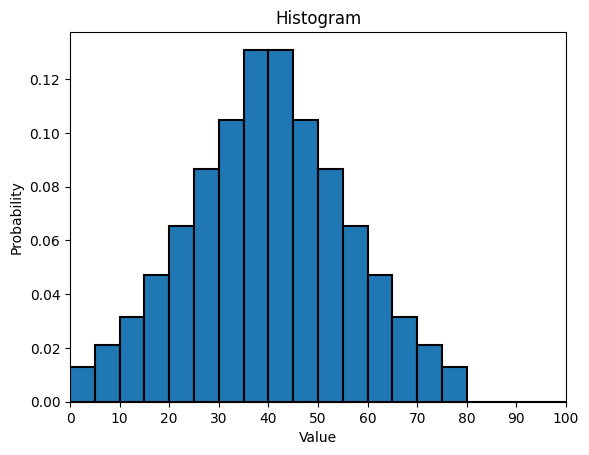

Sampled usages: 38%, 73%, carry over: 0%
Sampled usages: 53%, 53%, carry over: 11%
Sampled usages: 23%, 48%, carry over: 17%
Sampled usages: 38%, 23%, carry over: 0%
Sampled usages: 53%, 68%, carry over: 0%
Sampled usages: 23%, 43%, carry over: 21%
Sampled usages: 53%, 48%, carry over: 0%
Sampled usages: 43%, 53%, carry over: 1%
Sampled usages: 53%, 63%, carry over: 0%
Sampled usages: 28%, 53%, carry over: 16%
Sampled usages: 68%, 43%, carry over: 0%
Sampled usages: 33%, 58%, carry over: 11%
Sampled usages: 48%, 63%, carry over: 2%
Sampled usages: 33%, 53%, carry over: 13%
Sampled usages: 43%, 18%, carry over: 0%
Sampled usages: 53%, 43%, carry over: 0%
Sampled usages: 48%, 63%, carry over: 0%
Sampled usages: 58%, 48%, carry over: 11%
Sampled usages: 58%, 53%, carry over: 17%
Sampled usages: 53%, 38%, carry over: 28%
Sampled usages: 38%, 43%, carry over: 19%
Sampled usages: 53%, 28%, carry over: 0%
Sampled usages: 43%, 48%, carry over: 0%
Sampled usages: 28%, 48%, carry over: 0%
Sample

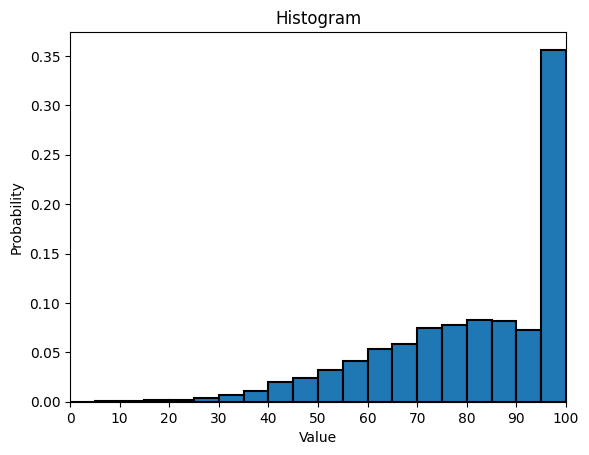

In [17]:
class Histogram:
    def __init__(self, bin_size):
        self.total_weight = 0
        self.bins = [0 for _ in range(int(100 / bin_size))]
        self.bin_size = bin_size

    def set_weight(self, bin_index, weight):
        if bin_index < 0 or bin_index >= len(self.bins):
            raise ValueError("Invalid bin index")

        self.total_weight -= self.bins[bin_index]
        self.bins[bin_index] = weight
        self.total_weight += weight

    def draw(self):
        x = [i * self.bin_size for i in range(len(self.bins))]
        heights = [w / self.total_weight for w in self.bins]
        plt.bar(x, heights, width=self.bin_size, align="edge", edgecolor="black", linewidth=1.5)
        plt.xlabel("Value")
        plt.ylabel("Probability")
        plt.title("Histogram")
        plt.xlim(min(x), max(x) + self.bin_size)
        plt.xticks([i * 10 for i in range(int(100 / 10) + 1)])
        plt.show()

    def sample(self):
        r = random.randint(1, self.total_weight)
        cumulative = 0
        for i, weight in enumerate(self.bins):
            cumulative += weight
            if r <= cumulative:
                return math.ceil(i * self.bin_size + (self.bin_size / 2))
        return 100
    
    def export(self, filename):
        with open(filename, "w") as f:
            f.write(f"bucket_size: {self.bin_size}\n")
            for weight in self.bins:
                f.write(f"{weight}\n")

    @staticmethod
    def add(hist1, hist2, simulated_epochs=10_000):
        """
        For each epoch, pick a random CPU usage from hist1 and hist2 and add them together, producing
        a datapoint for the new histogram. If combined usage exceeds 100%, carry over the excess to the next epoch.
        """
        max_bin_size = max(hist1.bin_size, hist2.bin_size)
        result = Histogram(max_bin_size)

        carry_over = 0
        for _ in range(simulated_epochs):
            usage1 = hist1.sample()
            usage2 = hist2.sample()
            print(f"Sampled usages: {usage1}%, {usage2}%, carry over: {carry_over}%")
            combined_usage = usage1 + usage2 + carry_over

            if combined_usage >= 100:
                carry_over = combined_usage - 100
                combined_usage = 100
                bin_index = int(100 / max_bin_size) - 1
            else:
                carry_over = 0
                bin_index = int(combined_usage / max_bin_size)

            result.bins[bin_index] += 1
            result.total_weight += 1
    
        return result


hist = None
with open(DATA_FILE, "r") as f:
    bin_index = 0
    for line in f:
        if line.startswith("bucket_size: "):
            bucket_size = float(line.strip().split(" ")[1])
            hist = Histogram(bucket_size)
        else:
            weight = int(line.strip())
            hist.set_weight(bin_index, weight)
            bin_index += 1

hist.draw()
combined = Histogram.add(hist, hist)
combined.draw()